<a href="https://colab.research.google.com/github/priyyyansh/Hotel-Data-Management-System/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Predict the price of a house
Dataset:**

Link: https://www.dropbox.com/sh/aypq6h3254207bs/AACzMLvo-XtK9sYAama6FW0Ia?dl=0

__Problem statement: The goal is to understand the relationship between house features and how these variables affect the house price.
Using more than one model, predict the price of the house using the given dataset. Please compare the accuracy of the models along with the drawbacks of each technique's assumptions before recommending the final prediction model.__

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
%matplotlib inline

In [4]:
Data = pd.read_excel('/content/DS - Assignment Part 1 data set.xlsx')
Data.head(10)

FileNotFoundError: [Errno 2] No such file or directory: '/content/DS - Assignment Part 1 data set.xlsx'

#Exploratory Data Analysis

In [ ]:
Data.info()

#HeatMap using seaborn library.

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(Data.corr(),
			cmap = 'BrBG',
			fmt = '.2f',
			linewidths = 2,
			annot = True)


In [ ]:
fig = plt.figure(figsize=(10,7))
fig.add_subplot(2,1,1)
sns.distplot(Data['House price of unit area'])
fig.add_subplot(2,1,2)
sns.boxplot(Data['House price of unit area'])
plt.tight_layout()

#Data Cleaning


# Removing Outlier's

In [ ]:
Data.isnull().sum()

In [ ]:
fig = plt.figure(figsize=(16,5))
sns.scatterplot(Data['House price of unit area'],Data['House size (sqft)'])

In [ ]:
Data[['House price of unit area']].sort_values(by = 'House price of unit area',ascending=False).head(20)

In [ ]:
for i in range(len(Data)):
  x = Data.loc[i , 'House price of unit area']
  if x == 117.5:
    print(i)
    break

Removing more outlier's

In [ ]:
Data = Data[(Data['House price of unit area']<65) & (Data['House price of unit area']>10)]

In [ ]:
sns.distplot(Data['House price of unit area'])

In [ ]:
fig = plt.figure(figsize=(16,5))
sns.scatterplot(Data['House price of unit area'],Data['House size (sqft)'])

In [ ]:
sns.pairplot(Data)

#Droping not so effective columns

In [ ]:
Data = Data.drop(['latitude', 'longitude', 'Transaction date'], axis = 1)

In [ ]:
Data.columns

#Splitting Dataset into Training and Testing
X and Y splitting

In [ ]:
x=Data[['House Age', 'Distance from nearest Metro station (km)','Number of convenience stores', 'Number of bedrooms','House size (sqft)']]
y=Data['House price of unit area']

In [ ]:
x.head(10)

# Creating Multilinear Regression Model


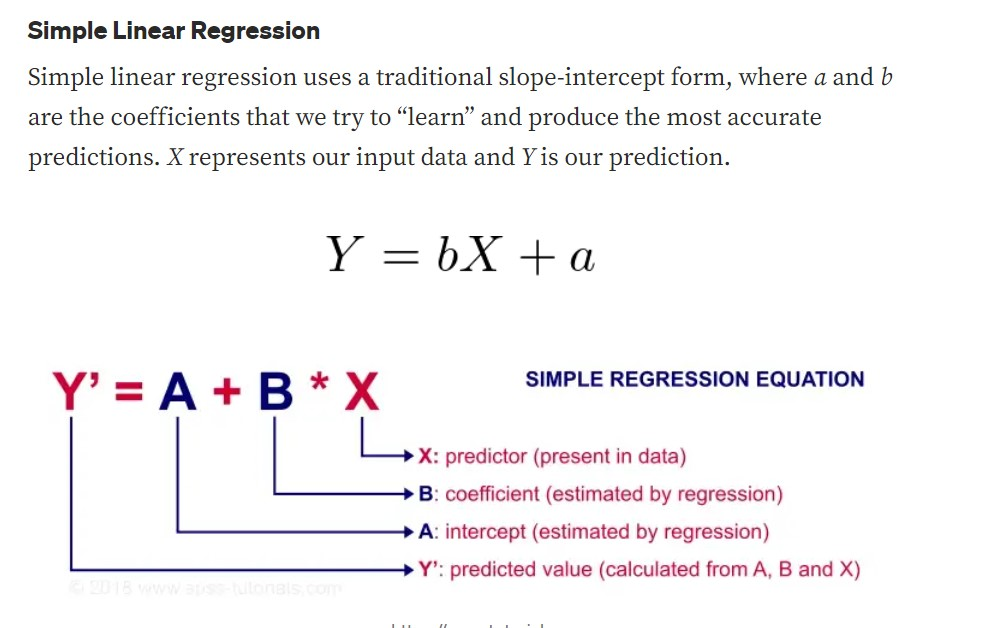

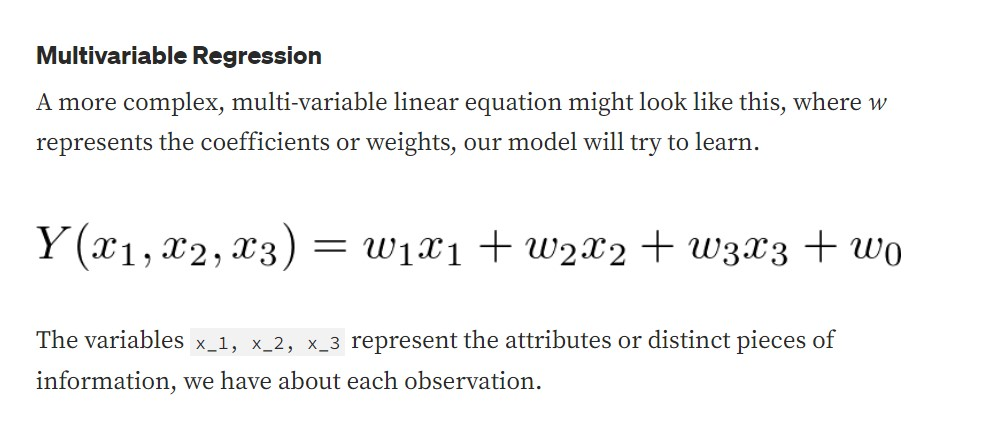

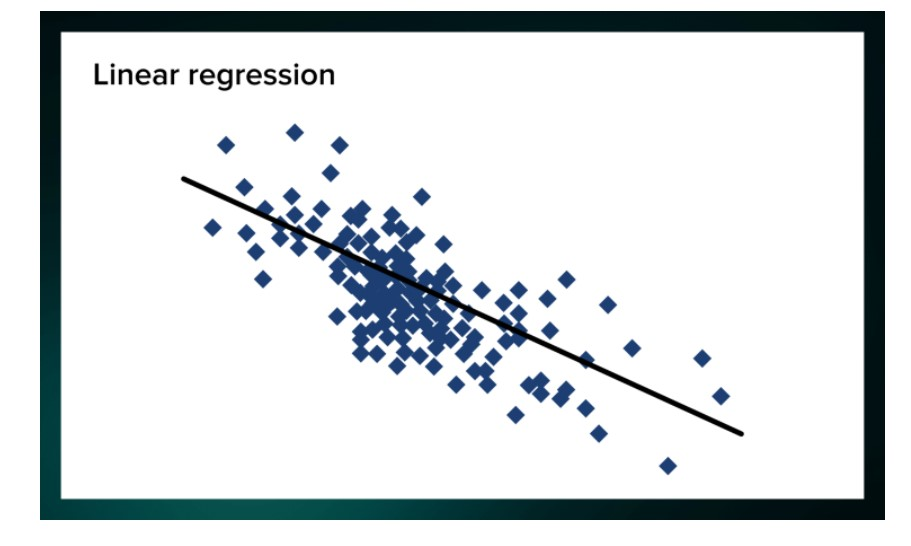

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=100,)

In [ ]:
from sklearn.linear_model import LinearRegression


In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred

In [ ]:
y_test

#Comparing Robustness of MAE, MSE and RME

In [ ]:
from sklearn import metrics

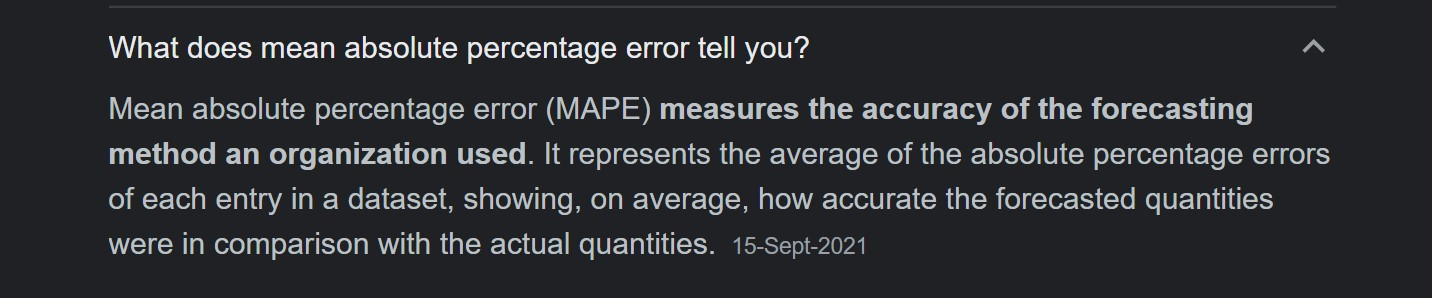

In [5]:
from sklearn.metrics import mean_absolute_percentage_error
print(mean_absolute_percentage_error(y_test, y_pred))

NameError: name 'y_test' is not defined

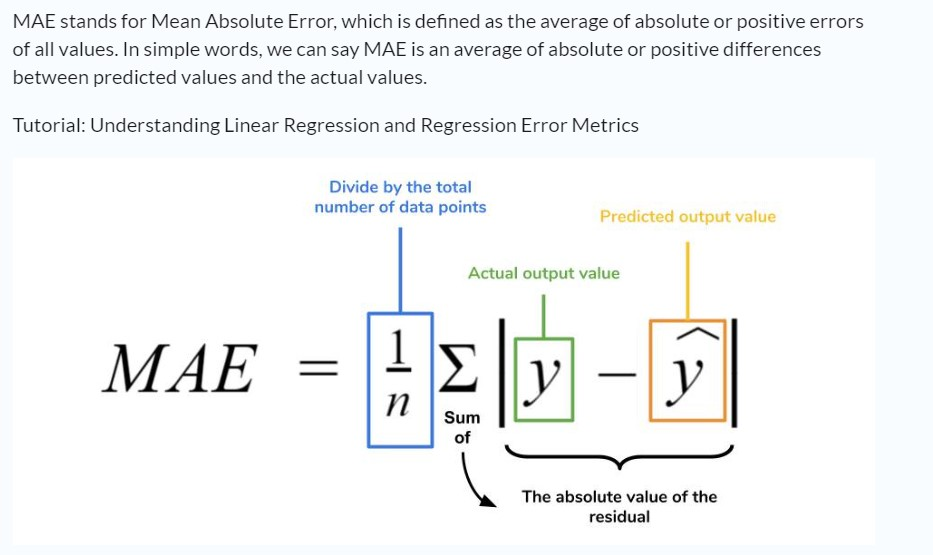

In [ ]:
MAE= metrics.mean_absolute_error(y_test,y_pred)
MAE

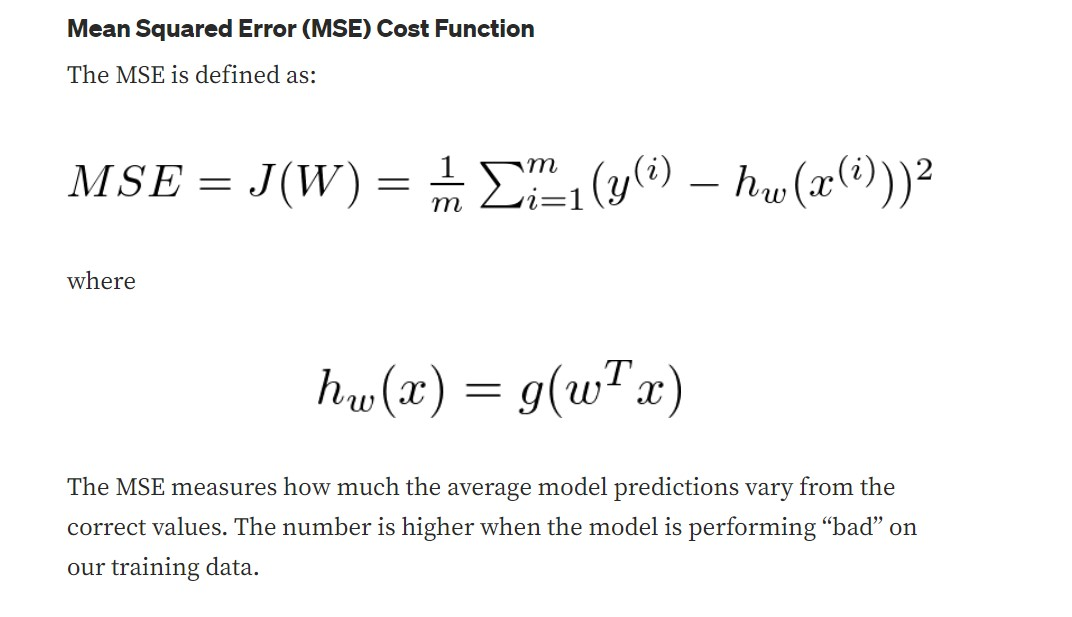

In [ ]:
MSE=metrics.mean_squared_error(y_test, y_pred)
MSE

In [ ]:
# Root Mean Squared Error (RMSE)

RME=np.sqrt(MSE)
RME

# Polynomial regression

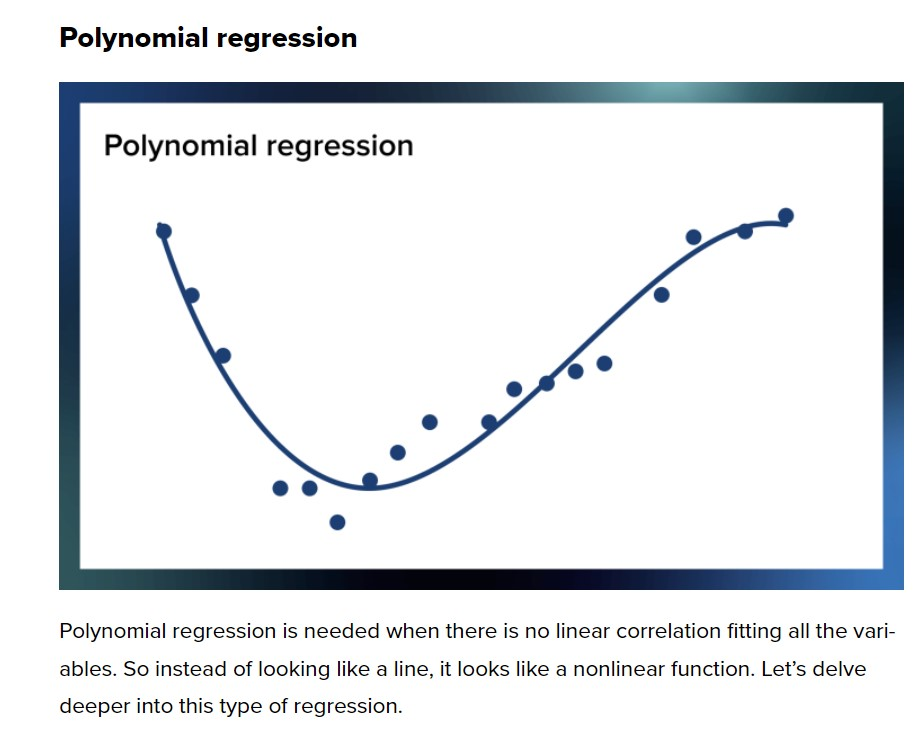

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly_regs= PolynomialFeatures(degree= 1)
x_poly= poly_regs.fit_transform(x)
lin_reg_2 =LinearRegression()
lin_reg_2.fit(x_poly, y)

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=100,)

In [ ]:
y_pred = lin_reg_2.predict(poly_regs.fit_transform(x_test))

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
print(mean_absolute_percentage_error(y_test, y_pred))

In [ ]:
from sklearn import metrics

MAE= metrics.mean_absolute_error(y_test,y_pred)
MSE=metrics.mean_squared_error(y_test, y_pred)
RME=np.sqrt(MSE)

In [ ]:
MAE

In [ ]:
MSE

In [ ]:
RME

In [ ]:
y_pred

In [ ]:
y_test

#SVM
#Support Vector Machine
The goal of the SVM algorithm is to create the best line or decision boundary that can segregate n-dimensional space into classes so that we can easily put the new data point in the correct category in the future. This best decision boundary is called a hyperplane.

SVM chooses the extreme points/vectors that help in creating the hyperplane. These extreme cases are called as support vectors, and hence algorithm is termed as Support Vector Machine. Consider the below diagram in which there are two different categories that are classified using a decision boundary or hyperplane:

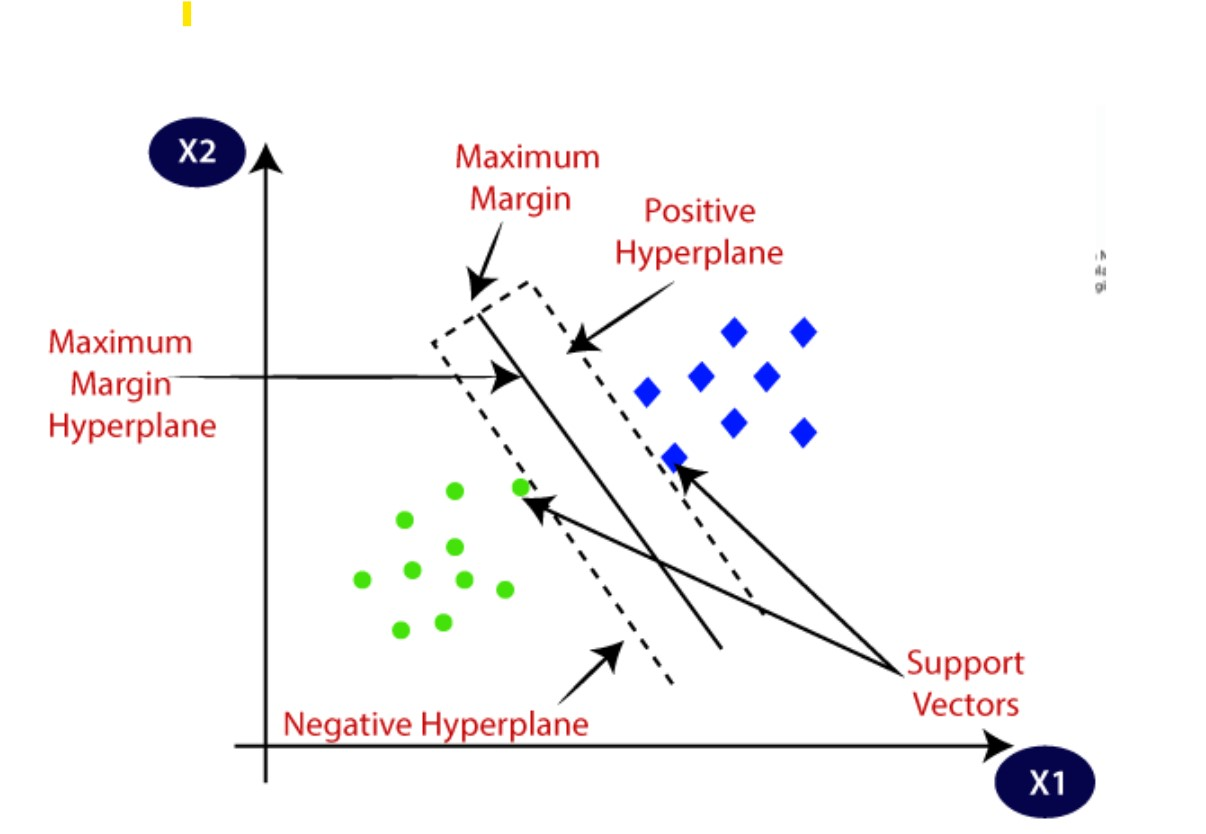

In [ ]:
x=Data[['House Age', 'Distance from nearest Metro station (km)','Number of convenience stores', 'Number of bedrooms', 'House size (sqft)']]
y=Data['House price of unit area']

In [ ]:
y=y.astype('int')

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.4, random_state=100,)


In [ ]:
from sklearn.svm import SVC


In [ ]:
model = SVC()

In [ ]:
model.fit(x_train,y_train ,sample_weight=None)


In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred

In [ ]:
y_test

In [ ]:
from sklearn import metrics

MAE= metrics.mean_absolute_error(y_test,y_pred)
MSE=metrics.mean_squared_error(y_test, y_pred)
RME=np.sqrt(MSE)

In [ ]:
MAE

In [ ]:
MSE

In [ ]:
RME

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
print(mean_absolute_percentage_error(y_test, y_pred))

#Conclusion :



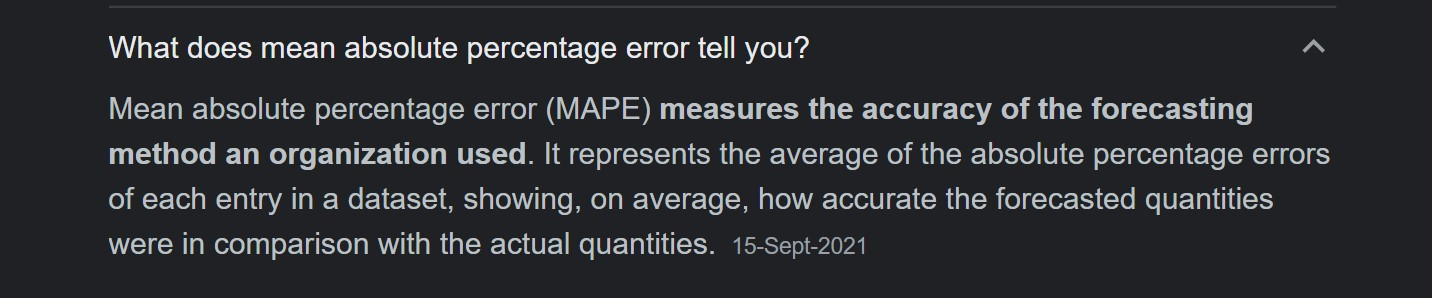

* The lower the ***Mean Absolute Percentage Error***  = The higher is the ***Accuracy*** of the Model.
* Thus the Good is the Model

* So

The **Mean Absolute Percentage Error of Multilinear Regression** Model is : 0.18126553933401301

The **Mean Absolute Percentage Error of Polynomial Regression** Model is : 0.180883158836327

The **Mean Absolute Percentage Error of Support Vector Machine** [ SVM ] Model is : 0.18300045294934703

* So according to above results for this given data set **Polynomial Regression Model** is Best.